# 1. Installing Dependecies and Dataset Download


In [1]:
!pip install langdetect datasets

from langdetect import detect


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.7 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=eb912d52c5d2a6951a20da726150f86c4818a1244ef9681aae1d1781656948e9
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dep

In [2]:
import pandas as pd
import kagglehub
from sklearn.utils import resample
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

path = kagglehub.dataset_download("atifaliak/youtube-comments-dataset")


# Load the dataset
df = pd.read_csv(path + '/YoutubeCommentsDataSet.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (18408, 2)


,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


#2. Data Cleaning and Preprocessing


In [3]:
# 2.1 Remove NaN values
print("Before dropping NaNs", df.shape)
df.dropna(inplace=True)
print("After dropping NaNs", df.shape)



# 2.2 Filter out non-English comments using langdetect

def is_english_comment(text):
    try:
        return detect(text) == 'en'
    except:
        return False

# Apply language filter
df['is_english'] = df['Comment'].apply(is_english_comment)
df = df[df['is_english']]
df = df.drop(columns=['is_english'])
print("After filtering non-English:", df.shape)

# 2.3 Remove stop words
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# Define a simple function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    words_filtered = [w for w in words if w.lower() not in stop_words]
    return ' '.join(words_filtered)

# Apply stop word removal
df['Comment'] = df['Comment'].apply(remove_stopwords)

# 2.4 Retain only desired sentiment labels
df = df[df['Sentiment'].isin(['positive', 'negative', 'neutral'])]
print("After retaining only pos/neg/neutral:", df.shape)

# Quick check of class distribution
print(df['Sentiment'].value_counts())


Before dropping NaNs (18408, 2)
After dropping NaNs (18364, 2)
After filtering non-English: (16271, 2)
After retaining only pos/neg/neutral: (16271, 2)
Sentiment
positive    10655
neutral      3320
negative     2296
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


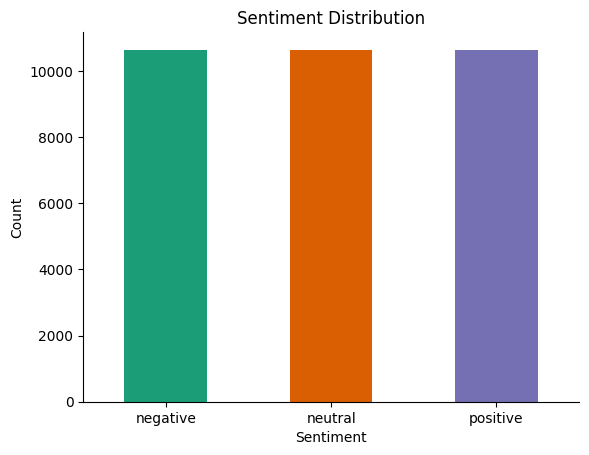

In [ ]:


# Separate by class
df_positive = df[df['Sentiment'] == 'positive']
df_neutral = df[df['Sentiment'] == 'neutral']
df_negative = df[df['Sentiment'] == 'negative']

# Find the largest class size
max_size = max(len(df_positive), len(df_neutral), len(df_negative))

# Upsample all classes to the size of the largest
df_positive_balanced = resample(df_positive, replace=True, n_samples=max_size, random_state=42)
df_neutral_balanced = resample(df_neutral, replace=True, n_samples=max_size, random_state=42)
df_negative_balanced = resample(df_negative, replace=True, n_samples=max_size, random_state=42)

# Combine into one balanced dataset
df_balanced = pd.concat([df_positive_balanced, df_neutral_balanced, df_negative_balanced])

# Shuffle the rows
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Count of each sentiment
sentiment_counts = df['Sentiment'].value_counts()


df.groupby('Sentiment').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.xticks(rotation=0)
plt.show()


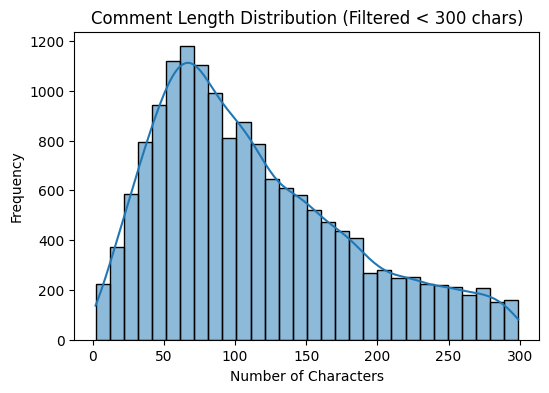

In [ ]:
df['comment_length'] = df['Comment'].str.len()
plt.figure(figsize=(6, 4))
sns.histplot(df[df['comment_length'] < 300]['comment_length'], bins=30, kde=True)
plt.title("Comment Length Distribution (Filtered < 300 chars)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


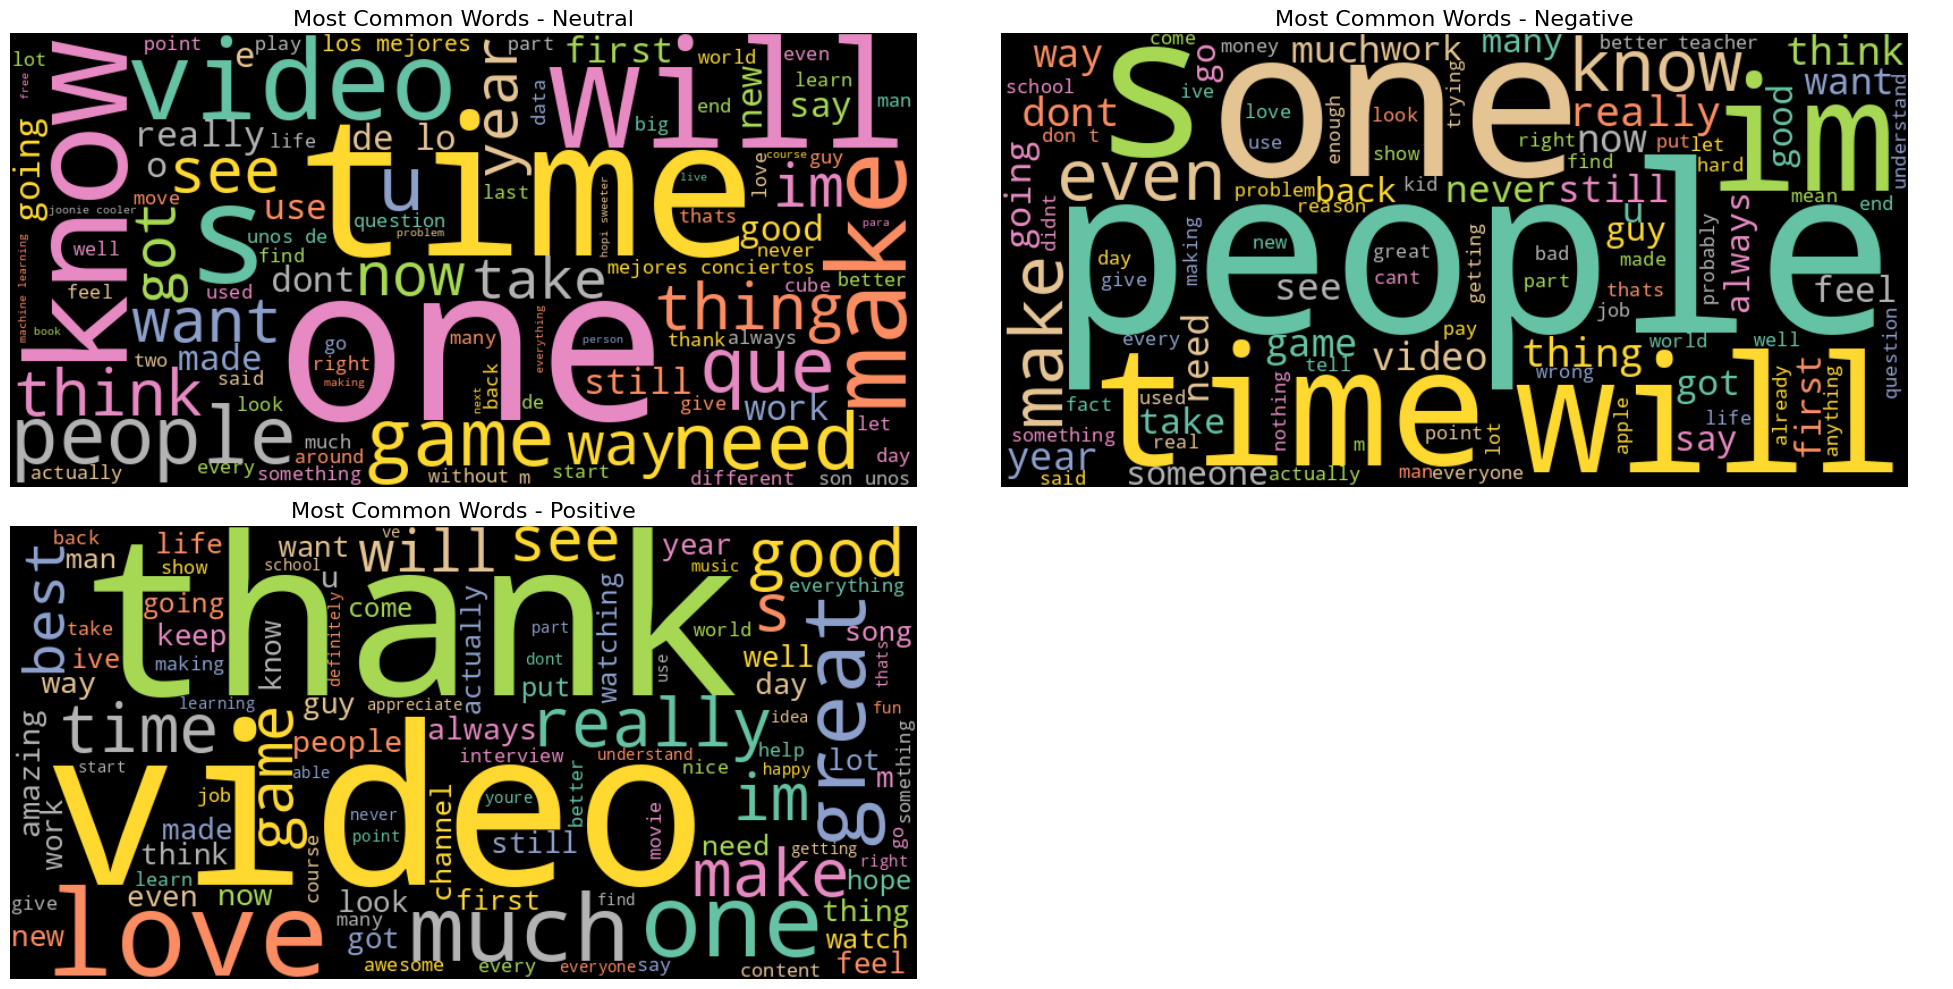

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

config = {
    'width': 800,
    'height': 400,
    'background_color': 'black',
    'colormap': 'Set2',
    'max_words': 100
}

sentiments = df['Sentiment'].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for i, sentiment in enumerate(sentiments):
    text = " ".join(df[df['Sentiment'] == sentiment]['Comment'].dropna().astype(str))
    wc = WordCloud(**config).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Most Common Words - {sentiment.capitalize()}", fontsize=16, color='black')
    axes[i].axis('off')

axes[3].axis('off')

plt.tight_layout()
plt.show()


#3. Model Preparation


In [4]:
# Split dataset into train and test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Sentiment'])
print(f"Train size: {train_df.shape[0]}, Test size: {test_df.shape[0]}")

# Prepare label encoding
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}
train_texts = list(train_df['Comment'])
train_labels = [label2id[label] for label in train_df['Sentiment']]
test_texts = list(test_df['Comment'])
test_labels = [label2id[label] for label in test_df['Sentiment']]

# Show a sample
print(train_texts[0], "->", train_df['Sentiment'].iloc[0])


Train size: 13016, Test size: 3255
lol tortoise segment pure gold bro shot fade flipped helplessly proceeded clap tortoise cheeks made em watch -> positive


#Model Initialization


In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Function to load model and tokenizer
def load_model_and_tokenizer(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    # If the model's classifier is pre-trained on a different number of labels, we reinitialize it
    model.config.id2label = id2label
    model.config.label2id = label2id
    return tokenizer, model

# Example: load BERT
bert_tokenizer, bert_model = load_model_and_tokenizer('bert-base-uncased')
print("BERT model and tokenizer loaded.")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT model and tokenizer loaded.


#Baseline Evaluation (Before Fine-Tuning)


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import torch
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def evaluate_model(tokenizer, model, test_texts, test_labels, batch_size=16):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    preds = []

    test_texts = [str(text) for text in test_texts]

    for i in tqdm(range(0, len(test_texts), batch_size), desc="Evaluating"):
        batch_texts = test_texts[i:i+batch_size]
        enc = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            output = model(**enc)
            logits = output.logits
            batch_preds = logits.argmax(dim=1).cpu().numpy()
            preds.extend(batch_preds)

        del enc, output, logits
        torch.cuda.empty_cache()

    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(test_labels, preds)
    return precision, recall, f1, accuracy


In [ ]:
model_names = {
    'BERT': 'bert-base-uncased',
    'RoBERTa': 'roberta-base',
    'DistilBERT': 'distilbert-base-uncased',
    'DeBERTa': 'microsoft/deberta-base'
}

print("Preloading tokenizers...")
tokenizers = {}
for name, ckpt in model_names.items():
    tokenizers[name] = AutoTokenizer.from_pretrained(ckpt)

# Evaluate all models
baseline_metrics = {}
for name, ckpt in model_names.items():
    print(f"\nEvaluating {name} before fine-tuning...")

    model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=3)

    # Evaluate
    precision, recall, f1, accuracy = evaluate_model(tokenizers[name], model, test_texts, test_labels, batch_size=8)

    # Free memory
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    baseline_metrics[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

    print(f"{name} - Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

baseline_metrics


Preloading tokenizers...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating:   0%|          | 0/407 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

DeBERTa - Accuracy: 0.20, Precision: 0.04, Recall: 0.20, F1: 0.07


{'BERT': {'Accuracy': 0.37719028588994774,
  'Precision': 0.4357867827678021,
  'Recall': 0.37719028588994774,
  'F1-score': 0.3840690736386663},
 'RoBERTa': {'Accuracy': 0.1414079311404857,
  'Precision': 0.22434216272688395,
  'Recall': 0.1414079311404857,
  'F1-score': 0.03551830777815324},
 'DistilBERT': {'Accuracy': 0.5321241930525669,
  'Precision': 0.6581771992922543,
  'Recall': 0.5321241930525669,
  'F1-score': 0.4887814318023746},
 'DeBERTa': {'Accuracy': 0.20442668306178913,
  'Precision': 0.04179026874764518,
  'Recall': 0.20442668306178913,
  'F1-score': 0.06939445851765685}}

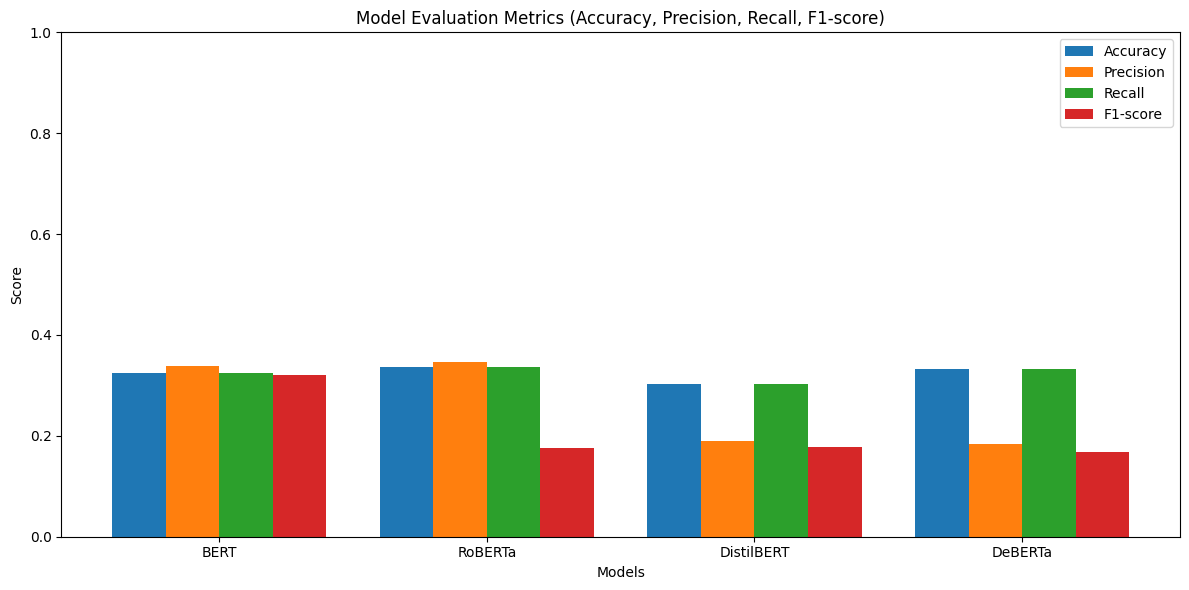

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data including Accuracy
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
models = list(baseline_metrics.keys())
data = [[baseline_metrics[model][metric] for model in models] for metric in metrics]

x = np.arange(len(models))
width = 0.2

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i*width, data[i], width, label=metric)

# Customize plot
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Evaluation Metrics (Accuracy, Precision, Recall, F1-score)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend()
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


#4. Fine-Tuning the Models


In [6]:
from torch.utils.data import Dataset

class CommentsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Optional: store metrics
fine_tuned_metrics = {}

def fine_tune_model(model_name, checkpoint, max_length=128):
    print(f"Fine‑tuning {model_name} using checkpoint: {checkpoint}...\n")

    # 1) Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=3)

    # 2) Build HF Datasets from your globals
    global train_texts, train_labels, test_texts, test_labels
    train_dataset = Dataset.from_dict({
        "text":   [str(t) for t in train_texts],
        "labels": train_labels
    })
    test_dataset = Dataset.from_dict({
        "text":   [str(t) for t in test_texts],
        "labels": test_labels
    })

    # 3) Tokenize with fixed max_length to avoid variable‑length tapes
    def tokenize_fn(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    train_dataset = train_dataset.map(tokenize_fn, batched=True)
    test_dataset  = test_dataset.map(tokenize_fn, batched=True)

    train_dataset.set_format("torch", columns=["input_ids","attention_mask","labels"])
    test_dataset .set_format("torch", columns=["input_ids","attention_mask","labels"])

    # 4) Define metrics
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc   = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(
            labels, preds, labels=[0,1,2], zero_division=0
        )
        return {
            "accuracy":       acc,
            "neg_precision": p[0], "neu_precision": p[1], "pos_precision": p[2],
            "neg_recall":    r[0], "neu_recall":    r[1], "pos_recall":    r[2],
            "neg_f1":        f1[0], "neu_f1":        f1[1], "pos_f1":        f1[2],
        }

    # 5) Training arguments (legacy flags)
    training_args = TrainingArguments(
        output_dir="./results",
        do_train=True,
        do_eval=True,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=1e-5,
        num_train_epochs=3,
        logging_steps=50,
        save_steps=500,
        save_total_limit=2,
    )

    # 6) Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
    )

    # 7) Train & Eval
    trainer.train()
    trainer.evaluate()

    # 8) Full preds for report + CM
    preds_output = trainer.predict(test_dataset)
    preds = np.argmax(preds_output.predictions, axis=-1)
    labels = preds_output.label_ids

    print("\n" + classification_report(
        labels,
        preds,
        target_names=["negative","neutral","positive"],
        digits=4
    ))

    # 9) Confusion matrix
    cm = confusion_matrix(labels, preds, labels=[0,1,2])
    names = ["negative","neutral","positive"]

    plt.figure(figsize=(6,5))
    im = plt.imshow(cm, aspect="auto")
    plt.xticks(np.arange(len(names)), names)
    plt.yticks(np.arange(len(names)), names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"{model_name} Confusion Matrix")
    for i in range(len(names)):
        for j in range(len(names)):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    # 10) Optionally store
    fine_tuned_metrics[model_name] = {
        "confusion_matrix": cm.tolist()
    }

    return model




Fine‑tuning BERT using checkpoint: bert-base-uncased...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13008 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Step,Training Loss
50,0.893800
100,0.858300
150,0.779600
200,0.677200
250,0.624100
300,0.670100
350,0.580300
400,0.542200
450,0.449100
500,0.554200


              precision    recall  f1-score   support

    negative     0.7392    0.6732    0.7047       459
     neutral     0.6683    0.6150    0.6406       665
    positive     0.8916    0.9310    0.9108      2129

    accuracy                         0.8300      3253
   macro avg     0.7664    0.7397    0.7520      3253
weighted avg     0.8244    0.8300    0.8265      3253



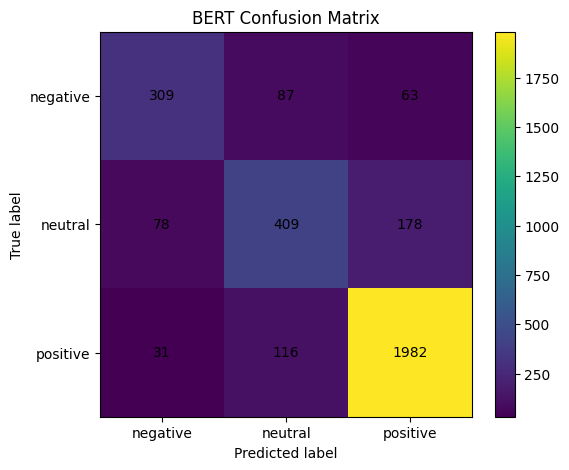

In [ ]:
bert_model = fine_tune_model('BERT', 'bert-base-uncased')


Fine‑tuning RoBERTa using checkpoint: roberta-base...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13008 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Step,Training Loss
50,0.899000
100,0.811300
150,0.724200
200,0.675700
250,0.620700
300,0.616900
350,0.566500
400,0.529600
450,0.488200
500,0.507700


Step,Training Loss
50,0.899000
100,0.811300
150,0.724200
200,0.675700
250,0.620700
300,0.616900
350,0.566500
400,0.529600
450,0.488200
500,0.507700


              precision    recall  f1-score   support

    negative     0.7588    0.7059    0.7314       459
     neutral     0.6905    0.6241    0.6556       665
    positive     0.8971    0.9375    0.9169      2129

    accuracy                         0.8408      3253
   macro avg     0.7821    0.7558    0.7679      3253
weighted avg     0.8353    0.8408    0.8373      3253



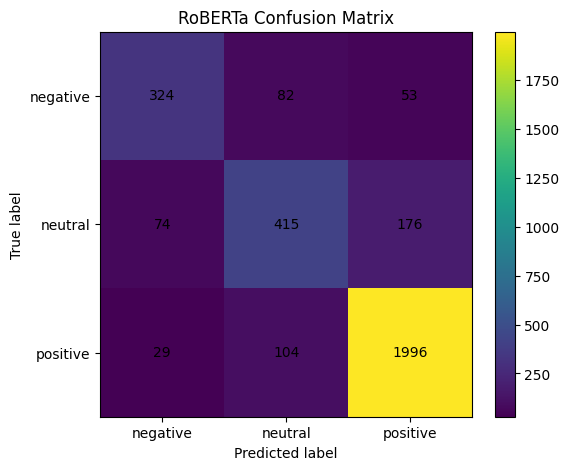

In [ ]:
roberta_model = fine_tune_model('RoBERTa', 'roberta-base')

Fine‑tuning DistilBERT using checkpoint: distilbert-base-uncased...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/13008 [00:00<?, ? examples/s]

Map:   0%|          | 0/3253 [00:00<?, ? examples/s]

Step,Training Loss
50,0.924300
100,0.860900
150,0.780500
200,0.680500
250,0.618700
300,0.612700
350,0.587400
400,0.558800
450,0.462600
500,0.488600


              precision    recall  f1-score   support

    negative     0.7449    0.6362    0.6863       459
     neutral     0.6438    0.6060    0.6243       665
    positive     0.8877    0.9319    0.9093      2129

    accuracy                         0.8235      3253
   macro avg     0.7588    0.7247    0.7399      3253
weighted avg     0.8177    0.8235    0.8195      3253



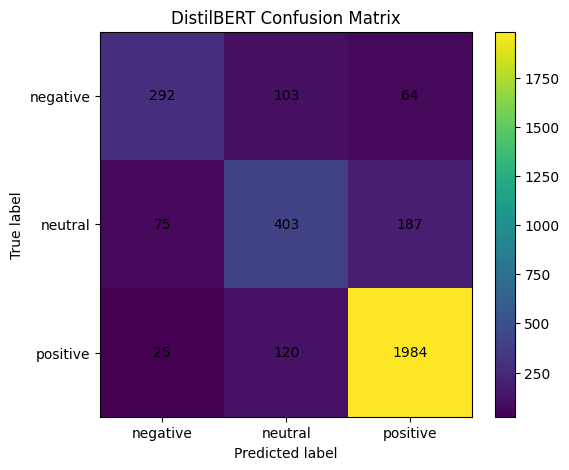

In [ ]:
distilbert_model = fine_tune_model('DistilBERT', 'distilbert-base-uncased')

Fine‑tuning DeBERTa using checkpoint: microsoft/deberta-base...



tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: anotherperson786786 (anotherperson786786-e-tv-s-lor-nd-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.972300
100,0.819200
150,0.755100
200,0.703600
250,0.653700
300,0.647000
350,0.599200
400,0.553600
450,0.591600
500,0.524200



              precision    recall  f1-score   support

    negative     0.7716    0.6993    0.7337       459
     neutral     0.6949    0.6416    0.6672       664
    positive     0.8953    0.9348    0.9146      2132

    accuracy                         0.8418      3255
   macro avg     0.7873    0.7586    0.7718      3255
weighted avg     0.8370    0.8418    0.8386      3255



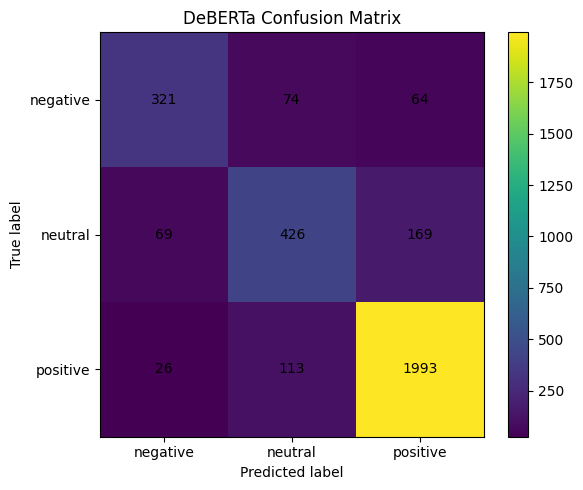

In [8]:
deberta_model = fine_tune_model("DeBERTa", "microsoft/deberta-base", max_length=128)

#5. Results and Visualization


In [ ]:
import matplotlib.pyplot as plt


# Prepare data for plotting
models_list = list(model_names.keys())
precisions_before = [baseline_metrics[m]['Precision'] for m in models_list]
recalls_before = [baseline_metrics[m]['Recall'] for m in models_list]
f1_before = [baseline_metrics[m]['F1-score'] for m in models_list]

precisions_after = [fine_tuned_metrics[m]['Precision'] for m in models_list]
recalls_after = [fine_tuned_metrics[m]['Recall'] for m in models_list]
f1_after = [fine_tuned_metrics[m]['F1-score'] for m in models_list]

# Plot metrics before fine-tuning
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Metrics Before Fine-Tuning')
metrics_names = ['Precision', 'Recall', 'F1-score']
for i, metric_values in enumerate([precisions_before, recalls_before, f1_before]):
    ax[i].bar(models_list, metric_values, color='skyblue')
    ax[i].set_title(metrics_names[i])
    ax[i].set_ylim(0, 1)
    for tick in ax[i].get_xticklabels():
        tick.set_rotation(45)
plt.show()

# Plot metrics after fine-tuning
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Metrics After Fine-Tuning')
for i, metric_values in enumerate([precisions_after, recalls_after, f1_after]):
    ax2[i].bar(models_list, metric_values, color='lightgreen')
    ax2[i].set_title(metrics_names[i])
    ax2[i].set_ylim(0, 1)
    for tick in ax2[i].get_xticklabels():
        tick.set_rotation(45)
plt.show()


NameError: name 'model_names' is not defined

In [10]:
output_dir = "deberta-finetuned"
!zip -r "{output_dir}.zip" "{output_dir}"

from google.colab import files
files.download(f"{output_dir}.zip")


  adding: deberta-finetuned/ (stored 0%)
  adding: deberta-finetuned/tokenizer_config.json (deflated 74%)
  adding: deberta-finetuned/model.safetensors (deflated 7%)
  adding: deberta-finetuned/special_tokens_map.json (deflated 83%)
  adding: deberta-finetuned/merges.txt (deflated 53%)
  adding: deberta-finetuned/vocab.json (deflated 59%)
  adding: deberta-finetuned/config.json (deflated 54%)
  adding: deberta-finetuned/tokenizer.json (deflated 82%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>